# 07 — StyleGAN Basics

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what makes **StyleGAN** different from the simple GAN of example 05: a **mapping network**, per-layer **style injection**, and the **truncation trick**
- Build a mapping network and inspect how it reshapes the latent distribution
- Implement the **truncation trick** on a trained GAN and measure its diversity-vs-typicality trade-off

## 🔗 Prerequisites

- ✅ Example 05 (simple GAN — trained again here as the base model)
- ✅ Example 06 (conditioning — a related form of generation control)

---

## Introduction

**StyleGAN** (Karras et al., 2019) generates some of the most realistic synthetic faces ever made. Three architectural ideas separate it from our simple GAN:

1. **Mapping network**: instead of feeding the Gaussian noise z straight into the generator, an 8-layer MLP first maps z → w. The *w-space* is free to take any shape, which lets the model organize it by visual attributes (pose, age, lighting) far better than the rigid Gaussian z-space.
2. **Style injection (AdaIN)**: w does not enter the generator once at the bottom — a learned transform of w rescales the feature maps at *every* layer. Coarse layers control pose/shape, fine layers control texture/color; mixing different w's at different layers ("style mixing") mixes those attributes.
3. **Truncation trick**: at sampling time, pull latents toward the average — trading diversity for typicality/quality.

A full StyleGAN needs days of GPU training, so this notebook does two honest small-scale experiments: (1) build a mapping network and watch it reshape the latent distribution; (2) apply the truncation trick to the example-05 GAN and *measure* the trade-off.


## Part 1 — The Mapping Network: z → w

We build a small mapping MLP and pass 5,000 Gaussian samples through it. The point to see: **w-space is not Gaussian** — even this untrained MLP warps the distribution, and in a trained StyleGAN that freedom is what lets w organize by visual attributes. (We check the shapes and distributions; no adversarial training is needed for this architecture walkthrough.)


z shape: (5000, 32)  →  w shape: (5000, 32)
z dim 0: mean +0.021  std 0.997   (Gaussian by construction)
w dim 0: mean +0.115  std 0.071   (whatever the MLP makes it)


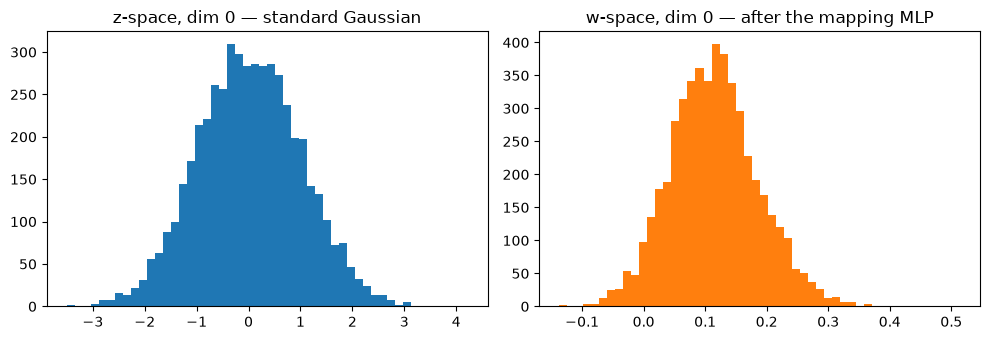


In StyleGAN, a learned transform of w then RESCALES the feature maps at
every generator layer (AdaIN 'style injection') — that per-layer entry point
is what enables style mixing across coarse and fine layers.


In [1]:
# WHAT/WHY: build a StyleGAN-style mapping network (z → w) and compare the
# distribution of z with the distribution of w — showing WHERE in the
# architecture the "style" latent space comes from.
import torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
Z_DIM = W_DIM = 32

# ── Mapping network: an MLP, exactly as in StyleGAN (theirs has 8 layers) ─
mapping = nn.Sequential(
    nn.Linear(Z_DIM, 64), nn.LeakyReLU(0.2),
    nn.Linear(64, 64),    nn.LeakyReLU(0.2),
    nn.Linear(64, W_DIM),
)

# ── Push 5,000 Gaussian z's through it ────────────────────────────────────
z = torch.randn(5000, Z_DIM)
with torch.no_grad():
    w = mapping(z)

print(f"z shape: {tuple(z.shape)}  →  w shape: {tuple(w.shape)}")
print(f"z dim 0: mean {z[:,0].mean():+.3f}  std {z[:,0].std():.3f}   (Gaussian by construction)")
print(f"w dim 0: mean {w[:,0].mean():+.3f}  std {w[:,0].std():.3f}   (whatever the MLP makes it)")

# ── Histograms: z is symmetric Gaussian; w is already warped ──────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(z[:, 0].numpy(), bins=50, color='tab:blue')
axes[0].set_title("z-space, dim 0 — standard Gaussian")
axes[1].hist(w[:, 0].numpy(), bins=50, color='tab:orange')
axes[1].set_title("w-space, dim 0 — after the mapping MLP")
plt.tight_layout(); plt.show()

print("\nIn StyleGAN, a learned transform of w then RESCALES the feature maps at")
print("every generator layer (AdaIN 'style injection') — that per-layer entry point")
print("is what enables style mixing across coarse and fine layers.")


## Part 2 — The Truncation Trick, Measured on a Real GAN

StyleGAN's truncation trick samples `w = w_avg + ψ·(w − w_avg)` with ψ < 1: latents are pulled toward the average, giving more *typical* (usually cleaner) but less *diverse* outputs.

Our simple GAN's latent prior is N(0, I), whose average is 0 — so truncation reduces to `z_trunc = ψ·z`. We train the example-05 GAN briefly, then sample at ψ = 0.3, 0.7, 1.0 and **measure diversity** (mean pairwise distance between samples) at each ψ. Watch the printed numbers fall as ψ shrinks.


Epoch 1/5 — D loss: 0.678  G loss: 1.527


Epoch 2/5 — D loss: 0.724  G loss: 1.704


Epoch 3/5 — D loss: 0.560  G loss: 3.035


Epoch 4/5 — D loss: 0.471  G loss: 2.929


Epoch 5/5 — D loss: 0.280  G loss: 3.017

psi   sample diversity (mean pairwise pixel distance)
0.3   11.64
0.7   15.77
1.0   17.03


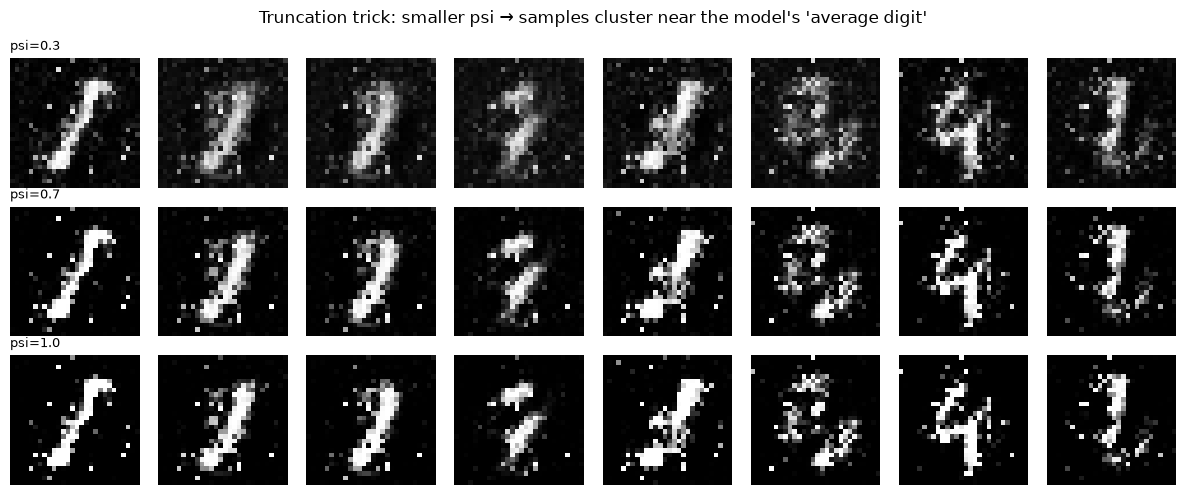


Read the numbers: diversity falls as psi shrinks — the truncation trade-off,
measured on our own GAN. StyleGAN does the same thing in w-space.


In [2]:
# WHAT/WHY: train the simple GAN from example 05, then sample with the
# truncation trick at three psi values — and QUANTIFY the trade-off by
# computing sample diversity (mean pairwise pixel distance) for each psi.
import torchvision, torchvision.transforms as T
import torch.optim as optim

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

# ── Same data + architecture as example 05 ────────────────────────────────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

# ── Brief adversarial training (see example 05 for the full walkthrough) ──
EPOCHS = 5
for epoch in range(EPOCHS):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {loss_D.item():.3f}  G loss: {loss_G.item():.3f}")

# ── Truncation trick: sample at psi = 0.3 / 0.7 / 1.0 from the SAME z's ───
G.eval()
psis = [0.3, 0.7, 1.0]
base_z = torch.randn(8, LATENT_DIM)      # same base latents for a fair comparison

fig, axes = plt.subplots(len(psis), 8, figsize=(12, 5))
print("\npsi   sample diversity (mean pairwise pixel distance)")
for row, psi in enumerate(psis):
    with torch.no_grad():
        imgs = G(psi * base_z).view(-1, 784)       # truncate: pull z toward 0
    # diversity = average L2 distance between all pairs of the 8 samples
    diversity = torch.pdist(imgs).mean().item()
    print(f"{psi:.1f}   {diversity:.2f}")
    for j in range(8):
        axes[row, j].imshow(imgs[j].view(28, 28), cmap='gray', vmin=-1, vmax=1)
        axes[row, j].axis('off')
    axes[row, 0].set_title(f"psi={psi}", loc='left', fontsize=9)
plt.suptitle("Truncation trick: smaller psi → samples cluster near the model's 'average digit'")
plt.tight_layout(); plt.show()

print("\nRead the numbers: diversity falls as psi shrinks — the truncation trade-off,")
print("measured on our own GAN. StyleGAN does the same thing in w-space.")


## 📚 References & Further Reading

**Papers:**
- Karras et al. (2019) — [StyleGAN: A Style-Based Generator Architecture](https://arxiv.org/abs/1812.04948) *(mapping network, style injection, truncation)*
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)
- Huang & Belongie (2017) — [AdaIN: Arbitrary Style Transfer](https://arxiv.org/abs/1703.06868) *(the normalization behind style injection)*

**Explore:** [thispersondoesnotexist.com](https://thispersondoesnotexist.com) shows StyleGAN output; the official [StyleGAN2 repo](https://github.com/NVlabs/stylegan2) has pretrained models if you have a GPU


## 📝 Summary

In **07 — StyleGAN Basics** you learned the three ideas that make StyleGAN more controllable than a plain GAN — mapping network (z → w), per-layer style injection, truncation — and ran two of them at small scale: you built a mapping network and saw it reshape the latent distribution (histograms above), and you applied the truncation trick to a GAN you trained, measuring how diversity falls as ψ shrinks (printed table). Full-scale StyleGAN training requires days of GPU time — use the pretrained models in the references to explore further.
